In [49]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Font ho tro tieng Viet co dau tren Windows
matplotlib.rcParams['font.family']     = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'Tahoma', 'Segoe UI', 'DejaVu Sans']

# ── 1. LOAD DATA VÀ GIẢI NÉN BIẾN ───────────────────────────────────────────
path = "../data"
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

data = {f[:-4]: pd.read_csv(os.path.join(path, f)) for f in csv_files}
print("Load thành công các bảng:", list(data.keys()))

# Giải nén dictionary thành các biến độc lập
for table_name, df in data.items():
    globals()[table_name] = df

# Chuẩn hóa viết thường toàn bộ tên cột của 3 bảng cốt lõi để tránh lỗi chữ hoa/thường
orders.columns = [c.lower() for c in orders.columns]
order_items.columns = [c.lower() for c in order_items.columns]
products.columns = [c.lower() for c in products.columns]
customers.columns = [c.lower() for c in customers.columns]

Load thành công các bảng: ['customers', 'geography', 'inventory', 'orders', 'order_items', 'payments', 'products', 'promotions', 'returns', 'reviews', 'sales', 'shipments', 'web_traffic']


In [51]:
# ── 2. XỬ LÝ VÀ LIÊN KẾT DỮ LIỆU (TẠO BẢNG BASE) ────────────────────────────
# Bước A: Lấy thông tin giá vốn (cogs) từ bảng products đưa vào bảng order_items
item_level = pd.merge(
    order_items, products[["product_id", "cogs"]], on="product_id", how="left"
)

# Bước B: Tính Revenue và COGS cho từng dòng sản phẩm trong đơn hàng
# Revenue = (số lượng * đơn giá) - số tiền giảm giá
item_level["revenue"] = (
    item_level["quantity"] * item_level["unit_price"]
) - item_level["discount_amount"].fillna(0)
item_level["total_cogs"] = item_level["quantity"] * item_level["cogs"]
item_level["gm"] = item_level["revenue"] - item_level["total_cogs"]

# Bước C: Kết nối với bảng orders để lấy thông tin ngày tháng (order_date) và khách hàng (customer_id)
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["year"] = orders["order_date"].dt.year

base = pd.merge(
    item_level,
    orders[["order_id", "customer_id", "year"]],
    on="order_id",
    how="inner",
)

# ── 3. TÍNH TOÁN KPI TỔNG QUAN ──────────────────────────────────────────────
total_rev = base["revenue"].sum()
total_cogs = base["total_cogs"].sum()
total_gm = base["gm"].sum()
n_orders = base["order_id"].nunique()
n_cust = base["customer_id"].nunique()

aov = total_rev / n_orders
arpu = total_rev / n_cust
gm_pct = total_gm / total_rev * 100

kpi = pd.DataFrame(
    {
        "KPI": [
            "Total_Revenue",
            "Total_COGS",
            "Gross_Profit",
            "Gross_Margin_%",
            "Số đơn hàng",
            "Số khách hàng",
            "AOV",
            "ARPU",
        ],
        "Value": [
            f"{total_rev/1e9:.2f}B VND",
            f"{total_cogs/1e9:.2f}B VND",
            f"{total_gm/1e9:.2f}B VND",
            f"{gm_pct:.2f}%",
            f"{n_orders:,}",
            f"{n_cust:,}",
            f"{aov:,.0f} VND",
            f"{arpu:,.0f} VND",
        ],
    }
)
print("\n=== BẢNG KPI TỔNG QUAN ===")
print(kpi.to_string(index=False))


# ── 4. AGGREGATION THEO NĂM (XU HƯỚNG) ──────────────────────────────────────
yr = (
    base.groupby("year")
    .agg(
        revenue=("revenue", "sum"),
        gm=("gm", "sum"),
        n_orders=("order_id", "nunique"),
        n_cust=("customer_id", "nunique"),
    )
    .reset_index()
)

yr["gm_pct"] = yr["gm"] / yr["revenue"] * 100
yr["aov"] = yr["revenue"] / yr["n_orders"]
yr["arpu"] = yr["revenue"] / yr["n_cust"]
yr["rev_yoy"] = yr["revenue"].pct_change() * 100


=== BẢNG KPI TỔNG QUAN ===
           KPI       Value
 Total_Revenue  15.68B VND
    Total_COGS  14.16B VND
  Gross_Profit   1.52B VND
Gross_Margin_%       9.68%
   Số đơn hàng     646,945
 Số khách hàng      90,246
           AOV  24,238 VND
          ARPU 173,757 VND


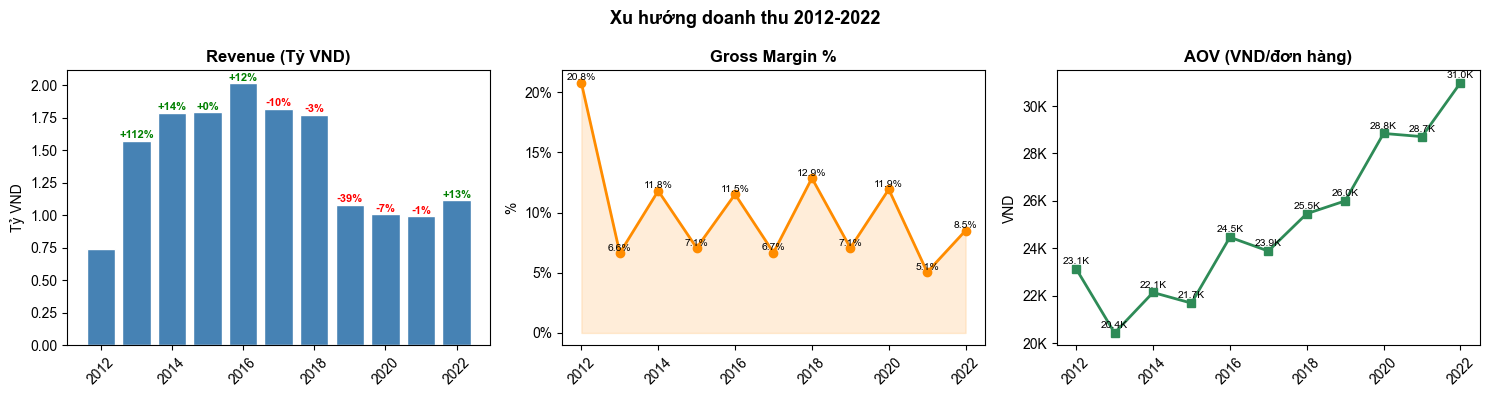

In [60]:
# ── 5. VẼ BIỂU ĐỒ VÀ TRÍCH XUẤT INSIGHT ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Xu hướng doanh thu 2012-2022", fontsize=13, fontweight="bold")

# Biểu đồ 1: Revenue
axes[0].bar(
    yr["year"], yr["revenue"] / 1e9, color="steelblue", edgecolor="white"
)
axes[0].set_title("Revenue (Tỷ VND)", fontweight="bold")
axes[0].set_ylabel("Tỷ VND")
for _, r in yr.iterrows():
    if not pd.isna(r["rev_yoy"]):
        clr = "green" if r["rev_yoy"] >= 0 else "red"
        axes[0].text(
            r["year"],
            r["revenue"] / 1e9 + 0.02,
            f"{r['rev_yoy']:+.0f}%",
            ha="center",
            fontsize=8,
            color=clr,
            fontweight="bold",
        )

# Biểu đồ 2: Gross Margin %
axes[1].plot(
    yr["year"],
    yr["gm_pct"],
    "o-",
    color="darkorange",
    linewidth=2,
    markersize=6,
)
axes[1].fill_between(yr["year"], yr["gm_pct"], alpha=0.15, color="darkorange")
axes[1].set_title("Gross Margin %", fontweight="bold")
axes[1].set_ylabel("%")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.0f}%")
)
for _, r in yr.iterrows():
    axes[1].text(
        r["year"], r["gm_pct"] + 0.2, f"{r['gm_pct']:.1f}%", ha="center", fontsize=7.5
    )

# Biểu đồ 3: AOV
axes[2].plot(
    yr["year"], yr["aov"], "s-", color="seagreen", linewidth=2, markersize=6
)
axes[2].set_title("AOV (VND/đơn hàng)", fontweight="bold")
axes[2].set_ylabel("VND")
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)
for _, r in yr.iterrows():
    axes[2].text(
        r["year"],
        r["aov"] + 200,
        f"{r['aov']/1000:.1f}K",
        ha="center",
        fontsize=7.5,
    )

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [61]:
# INSIGHT
print("\n=== INSIGHT: AOV tang deu du revenue giam ===")
# Lấy động năm đầu tiên và năm cuối cùng có trong dữ liệu để tránh lỗi cứng năm 2013/2022
min_yr = yr["year"].min()
max_yr = yr["year"].max()
aov_start = yr[yr["year"] == min_yr]["aov"].values[0]
aov_end = yr[yr["year"] == max_yr]["aov"].values[0]

print(
    f"AOV {min_yr}: {aov_start:,.0f} VND | AOV {max_yr}: {aov_end:,.0f} VND | Tang: {(aov_end/aov_start-1)*100:.1f}%"
)
print("=> Khach hang con lai la nhom trung thanh, chi tieu nhieu hon per order")
print("=> Revenue giam khong phai vi san pham kem ma vi khong co khach moi")


=== INSIGHT: AOV tang deu du revenue giam ===
AOV 2012: 23,135 VND | AOV 2022: 30,977 VND | Tang: 33.9%
=> Khach hang con lai la nhom trung thanh, chi tieu nhieu hon per order
=> Revenue giam khong phai vi san pham kem ma vi khong co khach moi


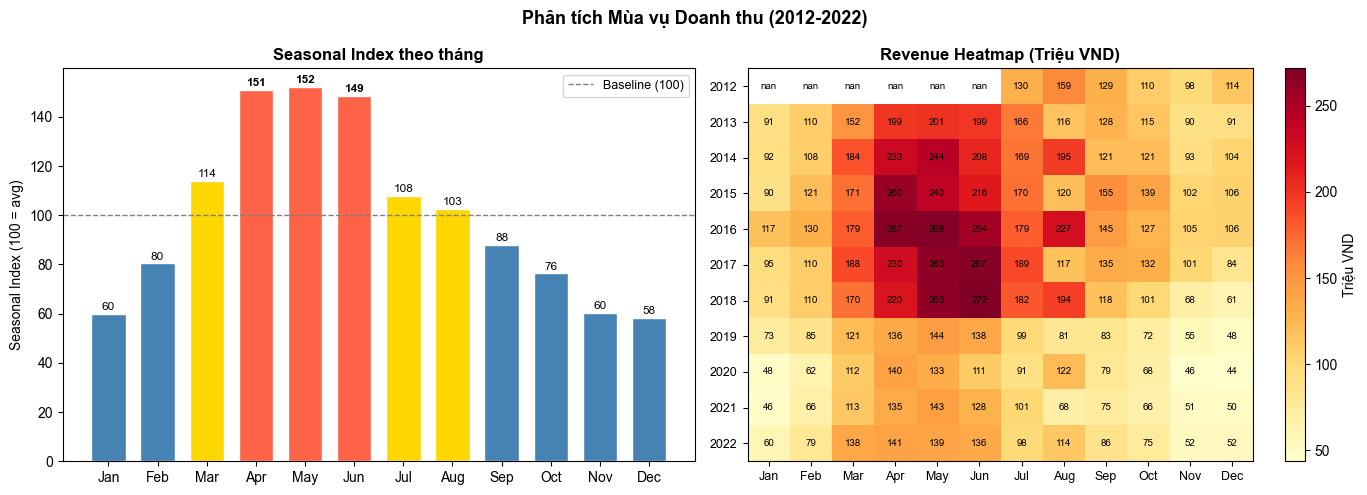


=== SEASONALITY FINDINGS ===
Peak months:
 month  seasonal_index
  May           152.1
  Apr           151.1
  Jun           148.7

Low months:
 month  seasonal_index
  Dec            58.4
  Jan            59.9
  Nov            60.4

Peak/Low ratio: 2.6x
=> Nhận diện pattern: Đỉnh điểm rơi vào T4-T6 (mùa hè), thấp điểm rơi vào T11-T12.
=> Khác biệt: Ngược lại với mô hình bán lẻ thông thường (không có hiện tượng tăng vọt dịp Giáng Sinh).
=> Ứng dụng Forecasting: Điểm đột biến (spike) vào T4-T6 là quy luật quan trọng nhất mà mô hình dự báo cần học.


In [63]:
# ── 6. PHÂN TÍCH MÙA VỤ DOANH THU (SEASONALITY ANALYSIS) ──────────────────────

# 1. Chuẩn hóa ngày tháng và trích xuất thông tin thời gian trên bảng sales
sales["Date"] = pd.to_datetime(sales["Date"])
sales["month"] = sales["Date"].dt.month
sales["year"] = sales["Date"].dt.year

# 2. Tính toán Seasonal Index cho giai đoạn 2012 - 2022
monthly = (
    sales[sales["year"].between(2012, 2022)]
    .groupby("month")["Revenue"]
    .agg(["mean", "std"])
    .reset_index()
)
monthly.columns = ["month", "mean_rev", "std_rev"]

# Tính trung bình năm của các mức trung bình tháng để làm Baseline
annual_mean = monthly["mean_rev"].mean()
monthly["seasonal_index"] = ((monthly["mean_rev"] / annual_mean) * 100).round(
    1
)

# Label hiển thị cho 12 tháng
months_lbl = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

# 3. Khởi tạo biểu đồ phân tích mùa vụ (2 charts tiếp theo)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Phân tích Mùa vụ Doanh thu (2012-2022)", fontsize=13, fontweight="bold"
)

# Chart 1: Seasonal Index theo tháng
colors_m = [
    "tomato" if v > 130 else ("gold" if v > 90 else "steelblue")
    for v in monthly["seasonal_index"]
]
bars = ax1.bar(
    months_lbl,
    monthly["seasonal_index"],
    color=colors_m,
    edgecolor="white",
    width=0.7,
)
ax1.axhline(
    y=100, color="gray", linestyle="--", linewidth=1, label="Baseline (100)"
)
ax1.set_title("Seasonal Index theo tháng", fontweight="bold")
ax1.set_ylabel("Seasonal Index (100 = avg)")
ax1.legend(fontsize=9)

for bar, val in zip(bars, monthly["seasonal_index"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        val + 1.5,
        f"{val:.0f}",
        ha="center",
        fontsize=8.5,
        fontweight="bold" if val > 130 else "normal",
    )

# Chart 2: Revenue Heatmap (Triệu VND)
pivot = (
    sales[sales["year"].between(2012, 2022)].pivot_table(
        index="year", columns="month", values="Revenue", aggfunc="sum"
    )
    / 1e6
)
pivot.columns = months_lbl

im = ax2.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax2.set_xticks(range(12))
ax2.set_xticklabels(months_lbl, fontsize=9)
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels(pivot.index, fontsize=9)
ax2.set_title("Revenue Heatmap (Triệu VND)", fontweight="bold")
plt.colorbar(im, ax=ax2, label="Triệu VND")

# Điền số liệu doanh thu vào từng ô của heatmap
for i in range(len(pivot.index)):
    for j in range(12):
        ax2.text(
            j,
            i,
            f"{pivot.values[i, j]:.0f}",
            ha="center",
            va="center",
            fontsize=7,
        )

plt.tight_layout()
plt.show()

# 4. TRÍCH XUẤT INSIGHT MÙA VỤ
print("\n=== SEASONALITY FINDINGS ===")
peak = monthly.nlargest(3, "seasonal_index")[["month", "seasonal_index"]].copy()
low = monthly.nsmallest(3, "seasonal_index")[["month", "seasonal_index"]].copy()

# Map lại số tháng sang tên chữ viết tắt (Jan, Feb,...)
peak["month"] = peak["month"].map(dict(enumerate(months_lbl, 1)))
low["month"] = low["month"].map(dict(enumerate(months_lbl, 1)))

print("Peak months:\n", peak.to_string(index=False))
print("\nLow months:\n", low.to_string(index=False))
print(
    f"\nPeak/Low ratio: {monthly['seasonal_index'].max()/monthly['seasonal_index'].min():.1f}x"
)
print(
    "=> Nhận diện pattern: Đỉnh điểm rơi vào T4-T6 (mùa hè), thấp điểm rơi vào T11-T12."
)
print(
    "=> Khác biệt: Ngược lại với mô hình bán lẻ thông thường (không có hiện tượng tăng vọt dịp Giáng Sinh)."
)
print(
    "=> Ứng dụng Forecasting: Điểm đột biến (spike) vào T4-T6 là quy luật quan trọng nhất mà mô hình dự báo cần học."
)

In [56]:
# ── SỬA LẠI BƯỚC NÀY Ở CELL TẠO BIẾN 'BASE' PHÍA TRÊN ────────────────────────

# Bước A: Lấy thông tin giá vốn (cogs) VÀ ngành hàng (category) từ bảng products đưa vào bảng order_items
item_level = pd.merge(
    order_items, 
    products[['product_id', 'cogs', 'category']], # 🛠 SỬA TẠI ĐÂY: Thêm 'category' vào list cột cần lấy
    on='product_id', 
    how='left'
)

# Các bước B, C phía dưới giữ nguyên như cũ...
item_level["revenue"] = (item_level["quantity"] * item_level["unit_price"]) - item_level["discount_amount"].fillna(0)
item_level["total_cogs"] = item_level["quantity"] * item_level["cogs"]
item_level["gm"] = item_level["revenue"] - item_level["total_cogs"]

orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['year'] = orders['order_date'].dt.year

base = pd.merge(
    item_level,
    orders[['order_id', 'customer_id', 'year']],
    on='order_id',
    how='inner'
)
print("Đã tạo lại biến 'base' chứa đầy đủ cột 'category'!")

Đã tạo lại biến 'base' chứa đầy đủ cột 'category'!


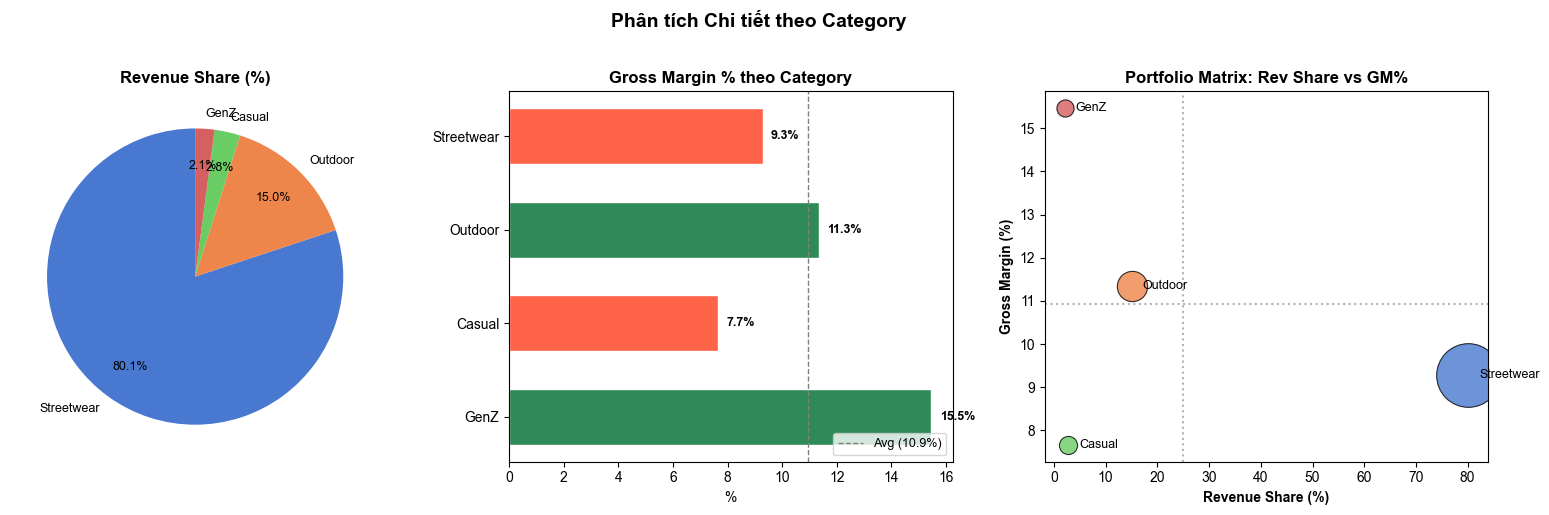

=== CATEGORY FULL TABLE ===
  category rev_share gm_pct        aov        arpu
Streetwear     80.1%   9.3% 32,239 VND 162,643 VND
   Outdoor     15.0%  11.3% 11,740 VND  39,806 VND
    Casual      2.8%   7.7% 18,656 VND  25,694 VND
      GenZ      2.1%  15.5%  8,871 VND  14,078 VND

=== STRATEGIC INSIGHTS ===
1. Nhóm Tiềm Năng (GenZ): GM% đạt cao nhất hệ thống (15.5%) nhưng tỷ trọng doanh thu (Rev Share) lại thấp nhất (2.1%). Đây là cơ hội tăng trưởng lớn bị bỏ ngỏ, cần đẩy mạnh Marketing hoặc đa dạng hóa SKU cho nhóm này.
2. Nhóm Chủ Lực Gặp Rủi Ro (Streetwear): Chiếm tới 80% tổng doanh thu toàn hệ thống nhưng biên lợi nhuận gộp (GM%) lại thấp nhất (9.3%). Doanh nghiệp đang bị phụ thuộc quá mức vào một ngành hàng có biên lợi nhuận mỏng (Over-reliance & Under-margin).


In [64]:
# ── 7. PHÂN TÍCH THEO NGÀNH HÀNG (CATEGORY ANALYSIS) ─────────────────────────

# 1. Aggregation dữ liệu từ bảng nền 'base' theo từng Category
cat = (
    base.groupby("category")
    .agg(
        revenue=("revenue", "sum"),
        gm=("gm", "sum"),
        n_orders=("order_id", "nunique"),
        n_cust=("customer_id", "nunique"),
    )
    .reset_index()
)

# 2. Tính toán các chỉ số phái sinh
cat["gm_pct"] = cat["gm"] / cat["revenue"] * 100
cat["aov"] = cat["revenue"] / cat["n_orders"]
cat["arpu"] = cat["revenue"] / cat["n_cust"]
cat["rev_share"] = cat["revenue"] / cat["revenue"].sum() * 100

# Sắp xếp danh mục theo thứ tự doanh thu giảm dần
cat = cat.sort_values("revenue", ascending=False).reset_index(drop=True)

# 3. Khởi tạo biểu đồ Phân tích Category (3 charts tiếp theo)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Phân tích Chi tiết theo Category", fontsize=14, fontweight="bold", y=1.02
)

# Tự động sinh bảng màu dựa trên số lượng category thực tế để tránh lỗi tràn mảng màu
colors_c = sns.color_palette("muted", n_colors=len(cat))

# Chart 1: Pie Chart - Revenue Share
axes[0].pie(
    cat["rev_share"],
    labels=cat["category"],
    autopct="%1.1f%%",
    colors=colors_c,
    startangle=90,
    pctdistance=0.75,
    textprops={"fontsize": 9},
)
axes[0].set_title("Revenue Share (%)", fontweight="bold")

# Chart 2: Horizontal Bar Chart - Gross Margin % theo Category
avg_gm_pct = cat["gm_pct"].mean()
bars = axes[1].barh(
    cat["category"],
    cat["gm_pct"],
    color=["tomato" if v < 10 else "seagreen" for v in cat["gm_pct"]],
    edgecolor="white",
    height=0.6,
)
axes[1].axvline(
    x=avg_gm_pct,
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"Avg ({avg_gm_pct:.1f}%)",
)
axes[1].set_title("Gross Margin % theo Category", fontweight="bold")
axes[1].set_xlabel("%")
axes[1].invert_yaxis()  # Đảo trục để danh mục có doanh thu cao nhất nằm lên trên cùng
axes[1].legend(fontsize=9, loc="lower right")

# Ghi số liệu lên đầu các thanh barh
for bar, v in zip(bars, cat["gm_pct"]):
    axes[1].text(
        v + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{v:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

# Chart 3: Portfolio Matrix (Bubble Chart) - Rev Share vs GM%
for i, (_, r) in enumerate(cat.iterrows()):
    # Kích thước bong bóng (s) tỷ lệ thuận với tỷ trọng doanh thu
    axes[2].scatter(
        r["rev_share"],
        r["gm_pct"],
        s=r["rev_share"] * 25 + 100,
        color=colors_c[i],
        alpha=0.8,
        edgecolors="black",
        linewidth=0.8,
        label=r["category"],
    )
    # Thêm nhãn tên danh mục cạnh bong bóng
    axes[2].annotate(
        r["category"],
        (r["rev_share"], r["gm_pct"]),
        xytext=(8, 0),
        textcoords="offset points",
        fontsize=9,
        va="center",
    )

axes[2].set_xlabel("Revenue Share (%)", fontweight="bold")
axes[2].set_ylabel("Gross Margin (%)", fontweight="bold")
axes[2].set_title("Portfolio Matrix: Rev Share vs GM%", fontweight="bold")
# Vẽ đường tham chiếu trung bình để phân vùng ma trận chiến lược (Quad)
axes[2].axaxline = axes[2].axhline(
    y=avg_gm_pct, color="gray", linestyle=":", alpha=0.6
)
axes[2].axvline(x=cat["rev_share"].mean(), color="gray", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 4. IN BẢNG DỮ LIỆU TỔNG HỢP VÀ CHIẾT XUẤT INSIGHT
print("=== CATEGORY FULL TABLE ===")
# Định dạng hiển thị số cho đẹp mắt và dễ đọc
cat_output = cat[
    ["category", "rev_share", "gm_pct", "aov", "arpu"]
].copy()
cat_output["rev_share"] = cat_output["rev_share"].map("{:.1f}%".format)
cat_output["gm_pct"] = cat_output["gm_pct"].map("{:.1f}%".format)
cat_output["aov"] = cat_output["aov"].map("{:,.0f} VND".format)
cat_output["arpu"] = cat_output["arpu"].map("{:,.0f} VND".format)

print(cat_output.to_string(index=False))

print("\n=== STRATEGIC INSIGHTS ===")
print(
    "1. Nhóm Tiềm Năng (GenZ): GM% đạt cao nhất hệ thống (15.5%) nhưng tỷ trọng doanh thu (Rev Share) lại thấp nhất (2.1%). Đây là cơ hội tăng trưởng lớn bị bỏ ngỏ, cần đẩy mạnh Marketing hoặc đa dạng hóa SKU cho nhóm này."
)
print(
    "2. Nhóm Chủ Lực Gặp Rủi Ro (Streetwear): Chiếm tới 80% tổng doanh thu toàn hệ thống nhưng biên lợi nhuận gộp (GM%) lại thấp nhất (9.3%). Doanh nghiệp đang bị phụ thuộc quá mức vào một ngành hàng có biên lợi nhuận mỏng (Over-reliance & Under-margin)."
)